<a href="https://colab.research.google.com/github/sakshi-coer/ComputerVisionLabsheets/blob/main/Labsheet_3_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                                    LABSHEET-3

######SAKSHI(49)
######BTECH CSE-A 3rd YEAR

1. Build a noise removal tool using gaussian,median and mean filters and compare their effectiveness on salt and pepper noise.

Mean Filter
MSE: 1285.2587
PSNR: 17.0409

Gaussian Filter
MSE: 842.0307
PSNR: 18.877523

Median Filter
MSE: 1370.9044
PSNR: 16.760733


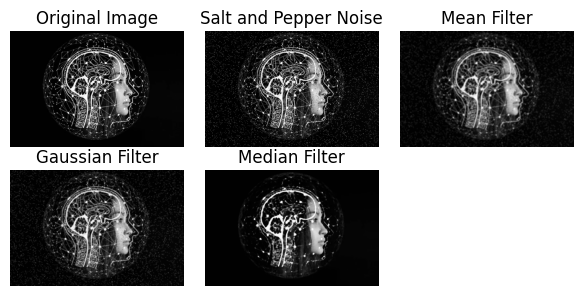

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("cs.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
noise = np.random.rand(image.shape[0], image.shape[1])
noisy_image = image.copy()
noisy_image[noise < 0.02] = 0
noisy_image[noise > 0.98] = 255
mean_filtered = cv2.blur(noisy_image, (5, 5))
gaussian_filtered = cv2.GaussianBlur(noisy_image, (5, 5), 0)
median_filtered = cv2.medianBlur(noisy_image, 5)

def mse(original, filtered):
    return np.mean((original.astype(np.float32) - filtered.astype(np.float32)) ** 2)

def psnr(original, filtered):
    error = mse(original, filtered)
    return 10 * np.log10((255 ** 2) / error)

print("Mean Filter")
print("MSE:", mse(image, mean_filtered))
print("PSNR:", psnr(image, mean_filtered))

print("\nGaussian Filter")
print("MSE:", mse(image, gaussian_filtered))
print("PSNR:", psnr(image, gaussian_filtered))

print("\nMedian Filter")
print("MSE:", mse(image, median_filtered))
print("PSNR:", psnr(image, median_filtered))

plt.figure(figsize=(6, 3))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(noisy_image)
plt.title("Salt and Pepper Noise")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(mean_filtered)
plt.title("Mean Filter")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(gaussian_filtered)
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(median_filtered)
plt.title("Median Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

2. Develop an edge detection demo using high pass filters and visualize the resulting edge maps.

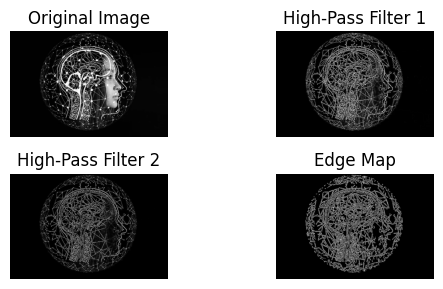

In [ ]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

kernel1 = np.array([[-1, -1, -1],
                    [-1,  8, -1],
                    [-1, -1, -1]])

kernel2 = np.array([[0, -1, 0],
                    [-1, 4, -1],
                    [0, -1, 0]])

edge1 = cv2.filter2D(gray, -1, kernel1)
edge2 = cv2.filter2D(gray, -1, kernel2)

plt.figure(figsize=(6, 3))

plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(edge1, cmap="gray")
plt.title("High-Pass Filter 1")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(edge2, cmap="gray")
plt.title("High-Pass Filter 2")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(cv2.Canny(gray, 100, 200), cmap="gray")
plt.title("Edge Map")
plt.axis("off")
plt.tight_layout()
plt.show()

3. Create an interactive blur tool with an adjustment kernal size for real time low pass filtering.

In [ ]:
from ipywidgets import interact, IntSlider
from IPython.display import display

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def blur_image(kernel_size):
    blurred = cv2.blur(image, (kernel_size, kernel_size))

    plt.figure(figsize=(6, 3))
    plt.imshow(blurred)
    plt.title(f"Low Pass Filter - Kernel Size: {kernel_size} x {kernel_size}")
    plt.axis("off")
    plt.show()
interact(
    blur_image,
    kernel_size=IntSlider(
        min=1,
        max=31,
        step=2,
        value=1,
        description="Kernel Size"
    )
);

interactive(children=(IntSlider(value=1, description='Kernel Size', max=31, min=1, step=2), Output()), _dom_cl…

4. Build a sharpening tool that applies unsharp masking to enhance fine details in an image .

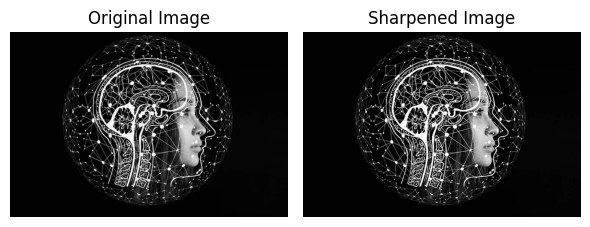

In [ ]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

blurred = cv2.GaussianBlur(image, (5, 5), 0)

sharpened = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharpened)
plt.title("Sharpened Image")
plt.axis("off")
plt.tight_layout()
plt.show()

5. Develop a custom convolution kernal designer where users input their own kernal matrix and apply it to an image.

Enter the 3x3 kernel values:
Row 1: 0 -1 0
Row 2: -1 4 2
Row 3: 0 -1 0


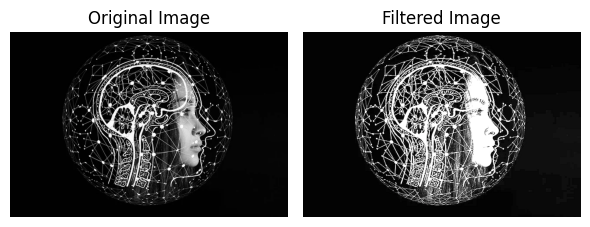

In [ ]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Enter the 3x3 kernel values:")

kernel = []

for i in range(3):
    row = list(map(float, input(f"Row {i + 1}: ").split()))
    kernel.append(row)

kernel = np.array(kernel)

result = cv2.filter2D(image, -1, kernel)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title("Filtered Image")
plt.axis("off")
plt.tight_layout()
plt.show()

6. Create a bilateral filtering demo that smooths an image while preserving edges and compare it with standard gaussian blur.


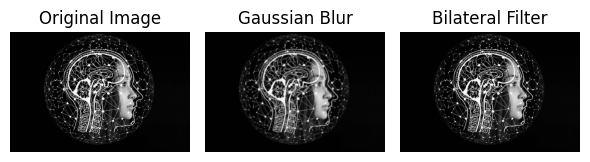

In [ ]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gaussian = cv2.GaussianBlur(image, (5, 5), 0)

bilateral = cv2.bilateralFilter(image, 9, 75, 75)

plt.figure(figsize=(6, 3))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gaussian)
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bilateral)
plt.title("Bilateral Filter")
plt.axis("off")
plt.tight_layout()
plt.show()

7. Build a denoising pipeline for old or scanned photographs using a combination of spatial filters.

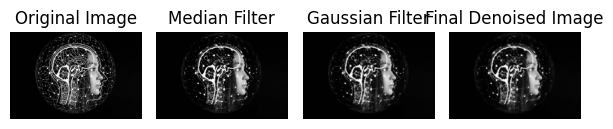

In [ ]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

median = cv2.medianBlur(image, 5)

gaussian = cv2.GaussianBlur(median, (5, 5), 0)

denoised = cv2.bilateralFilter(gaussian, 9, 75, 75)

plt.figure(figsize=(6, 3))

plt.subplot(1, 4, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(median)
plt.title("Median Filter")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(gaussian)
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(denoised)
plt.title("Final Denoised Image")
plt.axis("off")
plt.tight_layout()
plt.show()

8. Develop a program that reduces simple motion blur artifacts using high pass sharpening techniques.

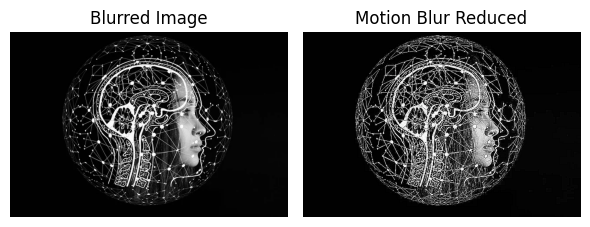

In [ ]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

kernel = np.array([
    [-1, -1, -1],
    [-1,  9, -1],
    [-1, -1, -1]
])

sharpened = cv2.filter2D(image, -1, kernel)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Blurred Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharpened)
plt.title("Motion Blur Reduced")
plt.axis("off")
plt.tight_layout()
plt.show()

9. Create a cartoonify effect generator using edge detection combined with smoothing filters.

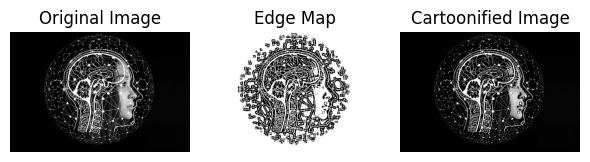

In [ ]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

smooth = cv2.bilateralFilter(image, 9, 75, 75)

gray = cv2.cvtColor(smooth, cv2.COLOR_RGB2GRAY)

edges = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    9,
    9
)

cartoon = cv2.bitwise_and(smooth, smooth, mask=edges)

plt.figure(figsize=(6, 3))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap="gray")
plt.title("Edge Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cartoon)
plt.title("Cartoonified Image")
plt.axis("off")
plt.tight_layout()
plt.show()

10. Build a comparison dashboard that reports PSNR/SSIM scores for different filtering techniques applied to the same noisy image.

Filtering Comparison Dashboard
---------------------------------------------
Filter         PSNR           SSIM           
---------------------------------------------
Mean           17.05          0.4100         
Gaussian       18.91          0.4831         
Median         16.76          0.7077         
Bilateral      17.37          0.5395         


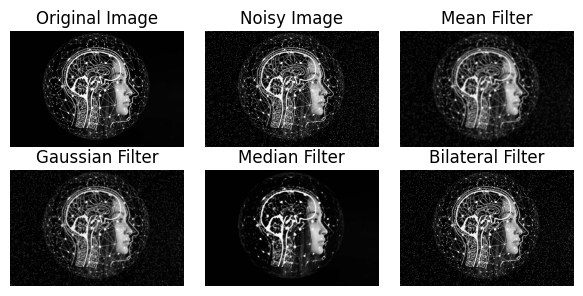

In [ ]:
from skimage.metrics import structural_similarity as ssim

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

noise = np.random.rand(image.shape[0], image.shape[1])

noisy_image = image.copy()
noisy_image[noise < 0.02] = 0
noisy_image[noise > 0.98] = 255

mean_filter = cv2.blur(noisy_image, (5, 5))
gaussian_filter = cv2.GaussianBlur(noisy_image, (5, 5), 0)
median_filter = cv2.medianBlur(noisy_image, 5)
bilateral_filter = cv2.bilateralFilter(noisy_image, 9, 75, 75)

def calculate_psnr(original, filtered):
    mse = np.mean((original.astype(np.float32) - filtered.astype(np.float32)) ** 2)
    if mse == 0:
        return float("inf")
    return 10 * np.log10((255 ** 2) / mse)

def calculate_ssim(original, filtered):
    original_gray = cv2.cvtColor(original, cv2.COLOR_RGB2GRAY)
    filtered_gray = cv2.cvtColor(filtered, cv2.COLOR_RGB2GRAY)
    return ssim(original_gray, filtered_gray, data_range=255)

filters = {
    "Mean": mean_filter,
    "Gaussian": gaussian_filter,
    "Median": median_filter,
    "Bilateral": bilateral_filter
}

print("Filtering Comparison Dashboard")
print("-" * 45)
print(f"{'Filter':<15}{'PSNR':<15}{'SSIM':<15}")
print("-" * 45)

for name, result in filters.items():
    psnr_value = calculate_psnr(image, result)
    ssim_value = calculate_ssim(image, result)
    print(f"{name:<15}{psnr_value:<15.2f}{ssim_value:<15.4f}")

plt.figure(figsize=(6, 3))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(noisy_image)
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(mean_filter)
plt.title("Mean Filter")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(gaussian_filter)
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(median_filter)
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(bilateral_filter)
plt.title("Bilateral Filter")
plt.axis("off")
plt.tight_layout()
plt.show()